In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("netflix_titles.csv")
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.shape

(8807, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [5]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [6]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [7]:
# Cleaning the data by dropping rows with missing values
df = df.dropna(subset=["type", "release_year", "duration", "rating", "country"])
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...


In [9]:
## Removing colunms which are not required for analysis
df = df.drop(columns=["show_id", "title", "director", "cast", "date_added", "description", "listed_in"])

In [8]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2223
cast             671
country            0
date_added         9
release_year       0
rating             0
duration           0
listed_in          0
description        0
dtype: int64

In [10]:
df.head(5)

,type,country,release_year,rating,duration
0,Movie,United States,2020,PG-13,90 min
1,TV Show,South Africa,2021,TV-MA,2 Seasons
4,TV Show,India,2021,TV-MA,2 Seasons
7,Movie,"United States, Ghana, Burkina Faso, United Kin...",1993,TV-MA,125 min
8,TV Show,United Kingdom,2021,TV-14,9 Seasons


In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 7970 entries, 0 to 8806
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   type          7970 non-null   str  
 1   country       7970 non-null   str  
 2   release_year  7970 non-null   int64
 3   rating        7970 non-null   str  
 4   duration      7970 non-null   str  
dtypes: int64(1), str(4)
memory usage: 373.6 KB


In [12]:
df.describe()

,release_year
count,7970.000000
mean,2013.885320
std,8.960918
min,1942.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


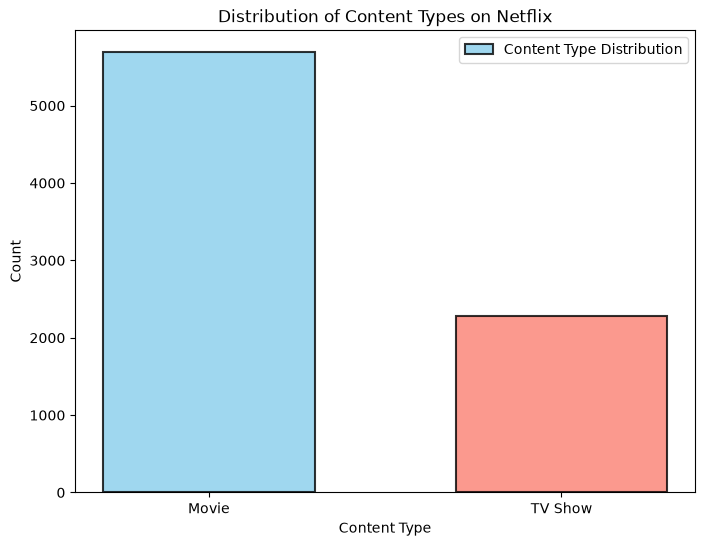

In [16]:
type_counts = df["type"].value_counts()
# Creating a bar chart to visualize the distribution of content types
plt.figure(figsize=(8, 6))
plt.bar(type_counts.index, type_counts.values, color=['skyblue', 'salmon'], edgecolor='black', width=0.6, alpha=0.8, linewidth=1.5, label='Content Type Distribution')
plt.title("Distribution of Content Types on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.savefig("charts_saved/content_type_distribution.png", dpi=300, bbox_inches='tight')
plt.legend()
plt.show()

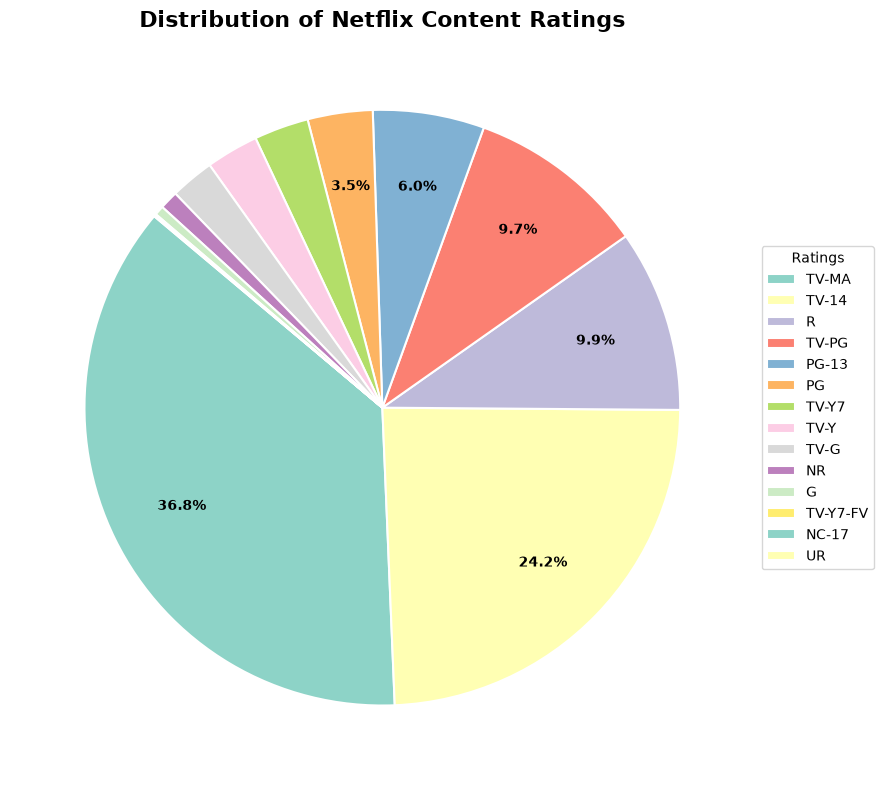

In [22]:
import matplotlib.pyplot as plt

rating_counts = df["rating"].value_counts()

colors = plt.cm.Set3.colors

fig, ax = plt.subplots(figsize=(10, 8))

wedges, texts, autotexts = ax.pie(
    rating_counts.values,
    colors=colors,
    autopct=lambda pct: f"{pct:.1f}%" if pct >= 3 else "",
    startangle=140,
    pctdistance=0.75,
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 1.5
    }
)

ax.legend(
    wedges,
    rating_counts.index,
    title="Ratings",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=10
)

plt.setp(autotexts, fontsize=10, fontweight="bold")

ax.set_title(
    "Distribution of Netflix Content Ratings",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "charts_saved/content_rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

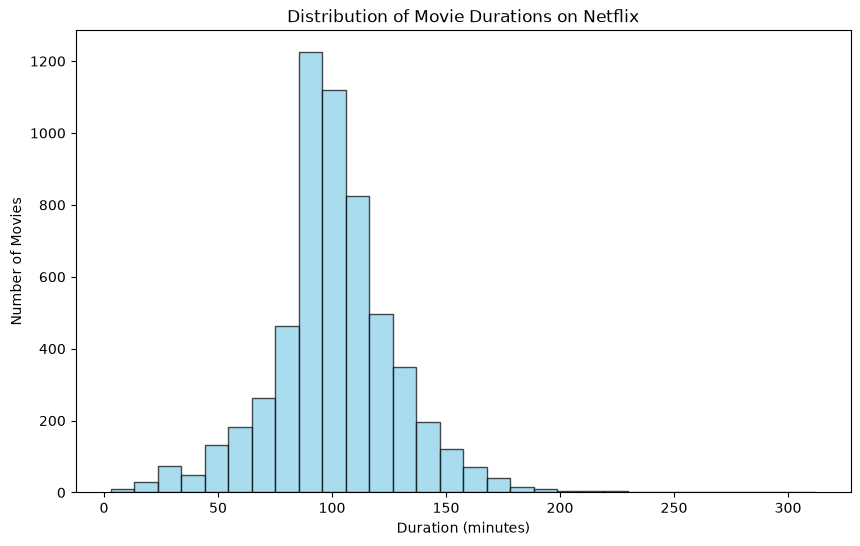

In [23]:
## Creating the histogram to visualize the duration of content [Movies] on Netflix
movies_df = df[df["type"] == "Movie"].copy()
movies_df["duration_int"] = movies_df["duration"].str.replace(" min", "").astype(int)

# Creating the histogram
plt.figure(figsize=(10, 6))
plt.hist(movies_df["duration_int"], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title("Distribution of Movie Durations on Netflix")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")
plt.savefig("charts_saved/movie_duration_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

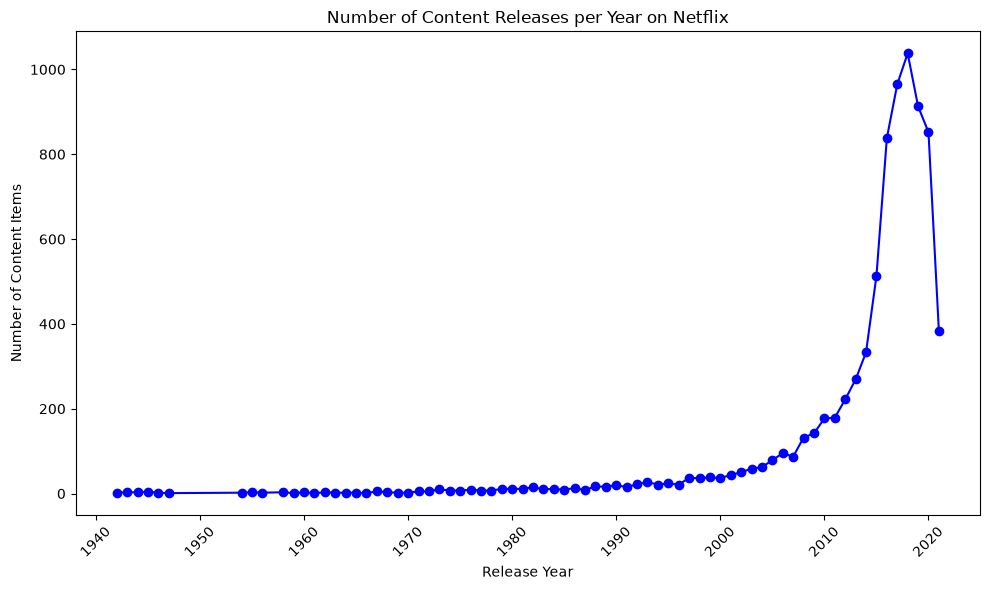

In [24]:
## Visualizing release vs number of content released each year on Netflix
release_year_counts = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.plot(release_year_counts.index, release_year_counts.values, marker='o', linestyle='-', color='blue')
plt.title("Number of Content Releases per Year on Netflix")
plt.xlabel("Release Year")
plt.ylabel("Number of Content Items")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("charts_saved/content_releases_per_year.png", dpi=300, bbox_inches='tight')
plt.show()

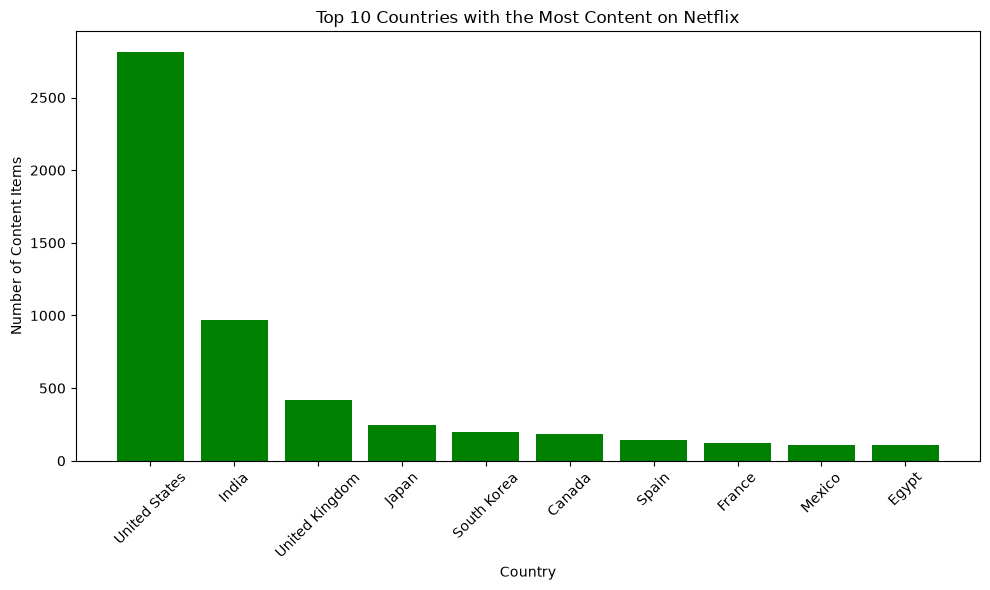

In [25]:
# Visualizing the top 10 countries with the most content on Netflix
country_counts = df["country"].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.bar(range(len(country_counts)), country_counts.values, color='green')
plt.title("Top 10 Countries with the Most Content on Netflix")
plt.xlabel("Country")
plt.ylabel("Number of Content Items")
plt.xticks(range(len(country_counts)), country_counts.index, rotation=45)
plt.tight_layout()
plt.savefig("charts_saved/top_countries_content.png", dpi=300, bbox_inches='tight')
plt.show()


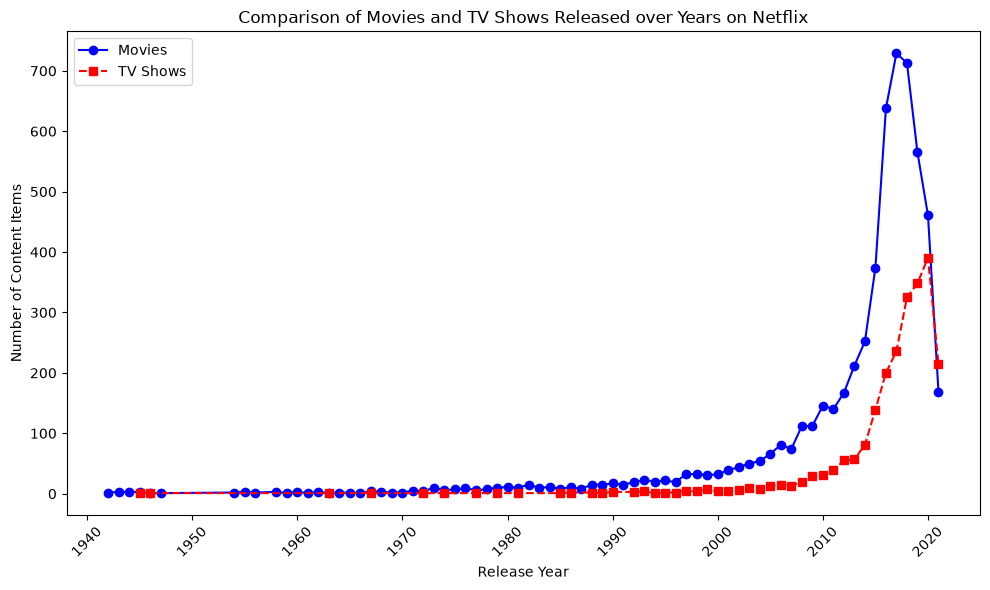

In [26]:
## Comparision of Movies and TV Shows released over years on Netflix
number_of_movies_per_year = df[df["type"] == "Movie"]["release_year"].value_counts().sort_index()
number_of_tv_shows_per_year = df[df["type"] == "TV Show"]["release_year"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.plot(number_of_movies_per_year.index, number_of_movies_per_year.values, marker='o', linestyle='-', color='blue', label='Movies')
plt.plot(number_of_tv_shows_per_year.index, number_of_tv_shows_per_year.values, marker='s', linestyle='--', color='red', label='TV Shows')
plt.title("Comparison of Movies and TV Shows Released over Years on Netflix")
plt.xlabel("Release Year")
plt.ylabel("Number of Content Items")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig("charts_saved/movies_vs_tv_shows.png", dpi=300, bbox_inches='tight')
plt.show()

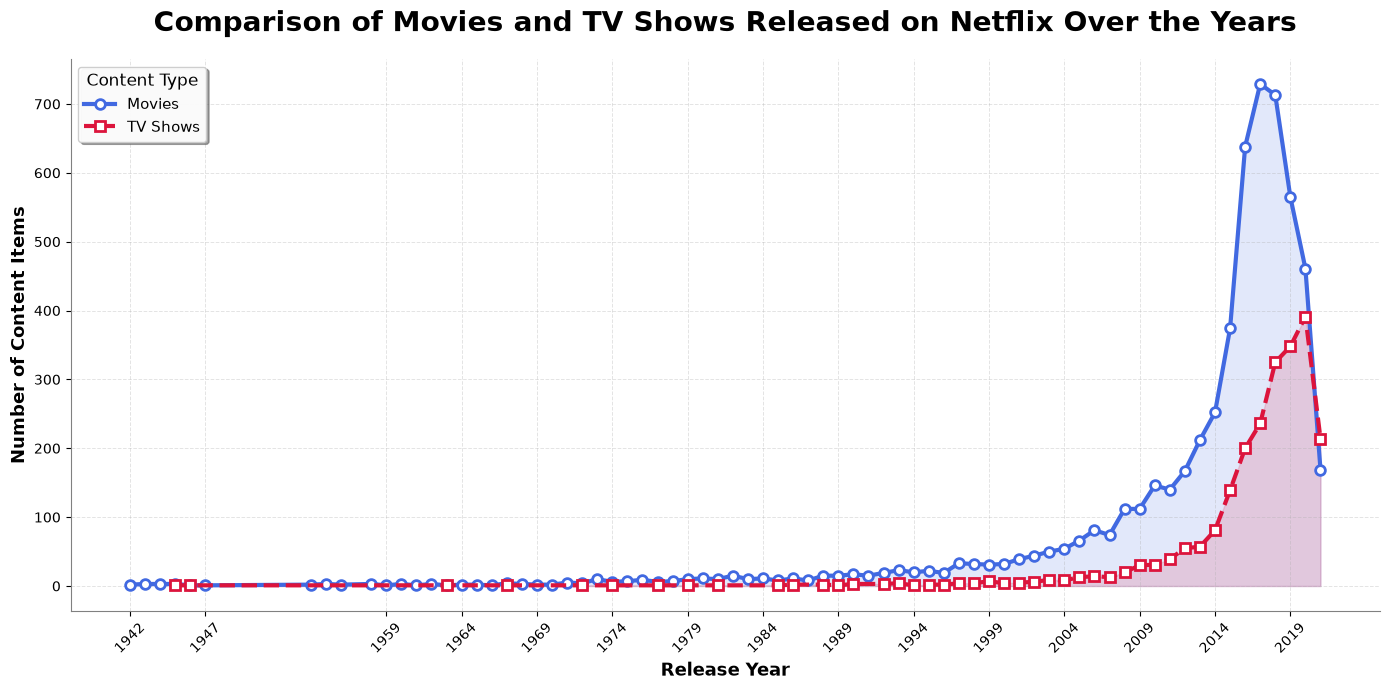

In [28]:
# Create figure
plt.figure(figsize=(14, 7))

# ---------------------------
# Movies Line
# ---------------------------
plt.plot(
    number_of_movies_per_year.index,
    number_of_movies_per_year.values,
    color="royalblue",
    linewidth=3,
    linestyle="-",
    marker="o",
    markersize=7,
    markerfacecolor="white",
    markeredgecolor="royalblue",
    markeredgewidth=2,
    label="Movies"
)

# Fill area under Movies line
plt.fill_between(
    number_of_movies_per_year.index,
    number_of_movies_per_year.values,
    color="royalblue",
    alpha=0.15
)

# ---------------------------
# TV Shows Line
# ---------------------------
plt.plot(
    number_of_tv_shows_per_year.index,
    number_of_tv_shows_per_year.values,
    color="crimson",
    linewidth=3,
    linestyle="--",
    marker="s",
    markersize=7,
    markerfacecolor="white",
    markeredgecolor="crimson",
    markeredgewidth=2,
    label="TV Shows"
)

# Fill area under TV Shows line
plt.fill_between(
    number_of_tv_shows_per_year.index,
    number_of_tv_shows_per_year.values,
    color="crimson",
    alpha=0.15
)

# ---------------------------
# Title & Labels
# ---------------------------
plt.title(
    "Comparison of Movies and TV Shows Released on Netflix Over the Years",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Release Year",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Number of Content Items",
    fontsize=13,
    fontweight="bold"
)

# ---------------------------
# Grid
# ---------------------------
plt.grid(
    axis="both",
    linestyle="--",
    linewidth=0.7,
    alpha=0.35
)

# ---------------------------
# X-axis Formatting
# ---------------------------
years = number_of_movies_per_year.index

# Show every 5th year for readability
plt.xticks(
    years[::5],
    rotation=45,
    fontsize=10
)

plt.yticks(fontsize=10)

# ---------------------------
# Legend
# ---------------------------
legend = plt.legend(
    title="Content Type",
    fontsize=11,
    title_fontsize=12,
    loc="upper left",
    frameon=True,
    fancybox=True,
    shadow=True
)

legend.get_frame().set_alpha(0.95)

# ---------------------------
# Customize Spines
# ---------------------------
ax = plt.gca()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("gray")
ax.spines["bottom"].set_color("gray")

# ---------------------------
# Layout
# ---------------------------
plt.tight_layout()

# ---------------------------
# Save Figure
# ---------------------------
plt.savefig(
    "charts_saved/movies_vs_tv_shows.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()